# 03 · Selección de variables (§4.2)

Punto de partida: las 42 variables transaccionales LRFM + acumuladas + de cambio (sin datos maestros).
Dos pasos, ambos evaluados **solo con los 4 bloques de validación** del pool de desarrollo (`02_particion`):

1. **Importancia por permutación** (caída de AUC) calculada *dentro del entrenamiento* de cada bloque, sobre una
   partición temporal interna con la misma brecha de 6 meses. Nunca se usan las etiquetas del bloque de validación.
   El promedio de los 4 bloques da el orden de candidatas; las de importancia media ≤ 0 se descartan.
2. **Ablación forward** (Loureiro et al., 2025): se agregan las candidatas una a una en ese orden y cada una se
   conserva solo si sube el AUC medio de los 4 bloques en más de `TOL = 0.001`. Se registra en cuántos bloques
   mejora como diagnóstico de consistencia.

Modelo de referencia para ambos pasos: XGBoost con parámetros fijos y moderados y `scale_pos_weight`.
El tuning por algoritmo viene después (`04_modelado`); aquí solo se decide el conjunto de variables.

In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from src import datos, particion, evaluacion
pd.set_option("display.width", 160)

df = datos.load()
FEATS = datos.features(df)
dev_mask, _ = particion.oot_split(df.mes_rank)
dev = df[dev_mask].reset_index(drop=True)          # el OOT no se toca en esta fase
folds = particion.temporal_folds(dev.mes_rank)

def ref_model(y):
    return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, scale_pos_weight=evaluacion.scale_pos_weight(y),
                         n_jobs=8, random_state=42, verbosity=0)

print(f"desarrollo: {len(dev):,} filas | {len(FEATS)} variables | {len(folds)} bloques")

desarrollo: 29,183 filas | 42 variables | 4 bloques


## 1 · Importancia por permutación dentro del entrenamiento

In [2]:
imps = []
for i, (tr, va) in enumerate(folds):
    train = dev.iloc[tr].reset_index(drop=True)
    itr, iva = particion.temporal_folds(train.mes_rank, n_folds=1)[0]   # partición interna, misma brecha
    y_itr = train.churn.iloc[itr].to_numpy()
    m = ref_model(y_itr).fit(train[FEATS].iloc[itr], y_itr)
    pi = permutation_importance(m, train[FEATS].iloc[iva], train.churn.iloc[iva],
                                scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=1)
    imps.append(pd.Series(pi.importances_mean, index=FEATS, name=f"bloque_{i+1}"))
    print(f"bloque {i+1}: interno train hasta {train.mes_obs.iloc[itr].max():%Y-%m}, "
          f"val {train.mes_obs.iloc[iva].min():%Y-%m}→{train.mes_obs.iloc[iva].max():%Y-%m}")
imp = pd.concat(imps, axis=1)
imp["media"] = imp.mean(axis=1)
imp["n_positivos"] = (imp.iloc[:, :4] > 0).sum(axis=1)
imp = imp.sort_values("media", ascending=False)
candidatas = imp.index[imp.media > 0].tolist()
print(f"\n{len(candidatas)} candidatas con importancia media > 0; descartadas: {len(FEATS) - len(candidatas)}")
imp.round(4)

bloque 1: interno train hasta 2022-09, val 2023-04→2023-07


bloque 2: interno train hasta 2023-01, val 2023-08→2023-11


bloque 3: interno train hasta 2023-05, val 2023-12→2024-03


bloque 4: interno train hasta 2023-09, val 2024-04→2024-07

37 candidatas con importancia media > 0; descartadas: 5


,bloque_1,bloque_2,bloque_3,bloque_4,media,n_positivos
compras_hist,0.0135,0.0081,0.0049,0.0091,0.0089,4
n_prod_u12,0.0061,0.0030,0.0092,0.0102,0.0071,4
n_ped_acum,0.0040,0.0069,0.0045,0.0086,0.0060,4
monto_u6,0.0054,0.0021,0.0083,0.0074,0.0058,4
monto_cv_u12,0.0031,0.0016,0.0058,0.0069,0.0044,4
n_ped_u12,0.0033,0.0057,0.0014,0.0054,0.0040,4
n_ped_u6,0.0047,0.0023,0.0032,0.0042,0.0036,4
monto_u12,0.0010,0.0022,0.0012,0.0095,0.0035,4
d_monto_m1,0.0023,0.0024,0.0022,0.0036,0.0026,4
meses_activos_u12,0.0039,0.0025,0.0013,0.0029,0.0026,4


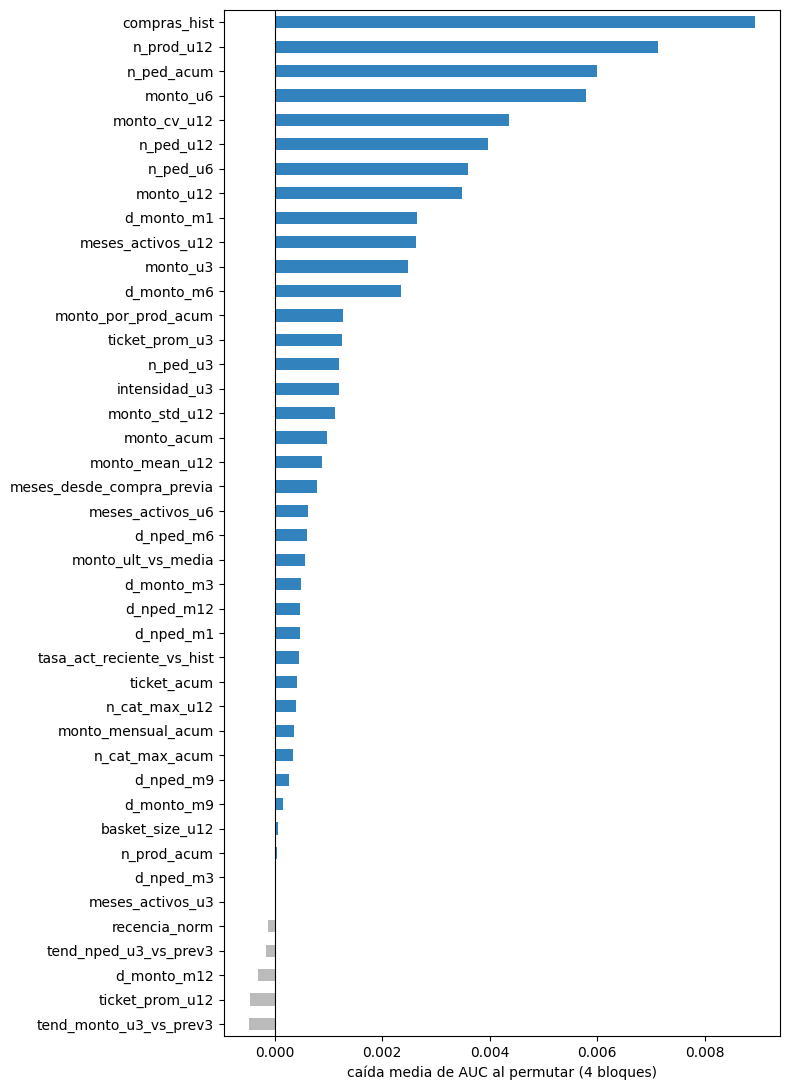

In [3]:
ax = imp.media.plot.barh(figsize=(8, 11), color=np.where(imp.media > 0, "#3182bd", "#bbbbbb"))
ax.invert_yaxis(); ax.axvline(0, c="k", lw=0.8); ax.set_xlabel("caída media de AUC al permutar (4 bloques)")
plt.tight_layout(); plt.show()

## 2 · Ablación forward

Se parte de la mejor candidata y se añade el resto en orden de importancia. Regla de conservación: el AUC medio
sube más de `TOL`. La variable se evalúa con el modelo re-entrenado por bloque, no con importancias.

In [4]:
TOL = 0.001
t0 = time.time()
sel = [candidatas[0]]
base = evaluacion.evaluar(ref_model, dev, sel, folds)
log = [{"paso": 1, "variable": sel[0], "accion": "inicio", "auc": base["auc"], "aucs": base["aucs"], "n_vars": 1}]
for k, v in enumerate(candidatas[1:], 2):
    r = evaluacion.evaluar(ref_model, dev, sel + [v], folds)
    mejora = (np.array(r["aucs"]) > np.array(base["aucs"])).sum()
    keep = r["auc"] - base["auc"] > TOL
    if keep:
        sel.append(v); base = r
    log.append({"paso": k, "variable": v, "accion": "conserva" if keep else "descarta",
                "auc": r["auc"], "aucs": r["aucs"], "bloques_mejoran": int(mejora), "n_vars": len(sel)})
    print(f"{k:2d} {v:28s} {'✔' if keep else '✘'}  auc={r['auc']:.4f} ({mejora}/4)  -> {len(sel)} vars")
print(f"\n{len(sel)} variables seleccionadas en {time.time()-t0:.0f}s")
forward = pd.DataFrame(log)

 2 n_prod_u12                   ✔  auc=0.7760 (4/4)  -> 2 vars


 3 n_ped_acum                   ✘  auc=0.7729 (1/4)  -> 2 vars


 4 monto_u6                     ✘  auc=0.7731 (1/4)  -> 2 vars


 5 monto_cv_u12                 ✔  auc=0.7804 (4/4)  -> 3 vars


 6 n_ped_u12                    ✔  auc=0.7825 (4/4)  -> 4 vars


...

33 d_monto_m9                   ✘  auc=0.7870 (1/4)  -> 6 vars


34 basket_size_u12              ✘  auc=0.7885 (2/4)  -> 6 vars


35 n_prod_acum                  ✘  auc=0.7875 (1/4)  -> 6 vars


36 d_nped_m3                    ✘  auc=0.7874 (2/4)  -> 6 vars


37 meses_activos_u3             ✘  auc=0.7873 (2/4)  -> 6 vars

6 variables seleccionadas en 52s


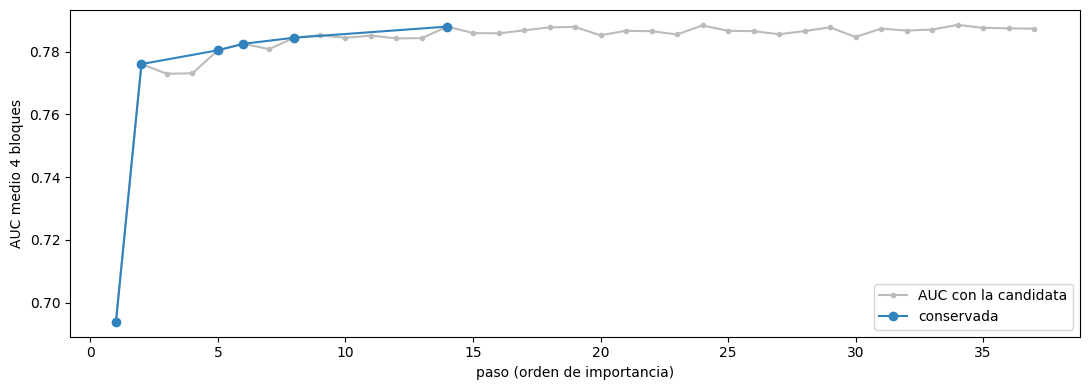

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(forward.paso, forward.auc, marker=".", c="#bbbbbb", label="AUC con la candidata")
ax.plot(forward.paso[forward.accion != "descarta"], forward.auc[forward.accion != "descarta"],
        marker="o", c="#3182bd", label="conservada")
ax.set_xlabel("paso (orden de importancia)"); ax.set_ylabel("AUC medio 4 bloques"); ax.legend()
plt.tight_layout(); plt.show()

## 3 · Conjunto completo vs seleccionado

In [6]:
full = evaluacion.evaluar(ref_model, dev, FEATS, folds)
comp = pd.DataFrame({
    "42 variables": {**dict(zip([f"auc_b{i+1}" for i in range(4)], full["aucs"])),
                     "auc_medio": full["auc"], "std": full["std"], "lift10_mensual": full["lift10"]},
    f"{len(sel)} seleccionadas": {**dict(zip([f"auc_b{i+1}" for i in range(4)], base["aucs"])),
                     "auc_medio": base["auc"], "std": base["std"], "lift10_mensual": base["lift10"]},
}).round(4)
comp

,42 variables,6 seleccionadas
auc_b1,0.7876,0.7964
auc_b2,0.7814,0.7824
auc_b3,0.7894,0.7964
auc_b4,0.7730,0.7765
auc_medio,0.7828,0.7879
std,0.0064,0.0087
lift10_mensual,2.2390,2.3580


## 4 · Exportación

In [7]:
spec = {"modelo_referencia": "XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight)",
        "regla_forward": f"sube AUC medio en más de {TOL}",
        "candidatas_orden_permutacion": candidatas,
        "descartadas_permutacion": [f for f in FEATS if f not in candidatas],
        "seleccionadas": sel,
        "auc_42": full["auc"], "auc_seleccionadas": base["auc"]}
(Path.cwd() / "variables_seleccionadas.json").write_text(json.dumps(spec, indent=2, ensure_ascii=False))

texto = f"""# Selección de variables (sem2)

Generado por `03_variables/variables.ipynb`. Pool de desarrollo: {len(dev):,} filas; 4 bloques de validación
temporal (`02_particion/particion.json`). Modelo de referencia: XGBoost con parámetros fijos.

## Importancia por permutación (dentro del entrenamiento, media de 4 bloques)
{len(candidatas)} de {len(FEATS)} variables con importancia media > 0. Descartadas: {", ".join(f"`{f}`" for f in FEATS if f not in candidatas) or "ninguna"}.

Top 15:
{imp[["media", "n_positivos"]].head(15).round(4).to_markdown()}

## Ablación forward
Regla: conservar si el AUC medio sube más de {TOL}.
**{len(sel)} variables seleccionadas**: {", ".join(f"`{f}`" for f in sel)}.

{forward[["paso", "variable", "accion", "auc", "bloques_mejoran", "n_vars"]].round(4).to_markdown(index=False)}

## Completo vs seleccionado
{comp.to_markdown()}

Lectura: la métrica es de selección (los mismos bloques se usan para elegir); no es una estimación final.
"""
(datos.ROOT / "reports" / "variables.md").write_text(texto)
print("-> variables_seleccionadas.json, reports/variables.md")

-> variables_seleccionadas.json, reports/variables.md
